# FSOI maps

Geographic views of the Food Sovereignty Index. This notebook does **not** rebuild the index —
it reads `fsoi_track_C_perHousehold.csv` and `fsoi_track_A_perHousehold.csv`, exported by the
last cells of `fsoi_indicator_selection.ipynb`. Re-run that notebook first if the index changes.

**Boundary data.** Türkiye admin-1 (province, 81 il) boundaries from HDX, *"Türkiye —
Subnational Administrative Boundaries"* (`cod-ab-tur`), hosted by OCHA FISS. Original source:
**General Command of Mapping (Harita Genel Müdürlüğü)** — the same agency behind
`Türkiye_Municipal_Areas.xlsx`, already used for city areas. Licence: **CC BY-IGO**. The cell
below downloads it once, keeps only the province layer, simplifies the geometry for
national-scale plotting, and caches it in `geo/`. The raw download is not kept.

**Reading these maps.** A map shows *where* scores sit, not *why*. Two cautions carried from
the main notebook: (1) which of non-metropolitan and old-metropolitan scores higher depends on
the aggregation method, so do not read a group ranking off the level map; (2) the one robust
causal result is a municipal-coverage effect, so a change map is not a food-sovereignty map.

In [1]:
%matplotlib inline
import io, os, zipfile, unicodedata
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

GEO_DIR = "geo"
GEO_FILE = os.path.join(GEO_DIR, "tur_admin1_simplified.geojson")
HDX_URL = ("https://data.humdata.org/dataset/d74086a0-f398-4474-9e12-1b9a70907bd0/resource/"
           "470bd810-2240-4ce0-b5c4-17434112ce41/download/tur_admin_boundaries.geojson.zip")
SIMPLIFY_TOLERANCE_DEG = 0.01   # ~1 km -- invisible at national scale, cuts file size a lot

GROUP_COLORS = {                 # identical to fsoi_indicator_selection.ipynb
    "Non-metropolitan": "#1f77b4",
    "New-metropolitan (2012)": "#ff7f0e",
    "Old-metropolitan": "#2ca02c",
}
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

In [2]:
# Acquire boundaries once; afterwards read the cached, simplified file.
if not os.path.exists(GEO_FILE):
    os.makedirs(GEO_DIR, exist_ok=True)
    resp = requests.get(HDX_URL, timeout=180, headers={"User-Agent": "Mozilla/5.0 (thesis research; open data)"})
    resp.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(resp.content)) as z:
        raw = gpd.read_file(io.BytesIO(z.read("tur_admin1.geojson")))
    raw = raw[["adm1_name", "adm1_pcode", "center_lat", "center_lon", "geometry"]].copy()
    raw["geometry"] = raw.geometry.simplify(SIMPLIFY_TOLERANCE_DEG, preserve_topology=True)
    raw.to_file(GEO_FILE, driver="GeoJSON")
    print(f"Downloaded, simplified and cached -> {GEO_FILE}")

provinces = gpd.read_file(GEO_FILE)
assert len(provinces) == 81, f"expected 81 provinces, got {len(provinces)}"
print(f"{len(provinces)} provinces, CRS {provinces.crs}, file {os.path.getsize(GEO_FILE)/1e6:.2f} MB")

81 provinces, CRS EPSG:4326, file 0.37 MB


## Matching province names to `Location_Name`

`adm1_name` is ASCII-folded ("Adiyaman"), and the Turkish-script column in the source carries
a broken lowercase dotted-i (a combining dot, "i̇"), so neither matches our names directly.
Both sides are folded to the same plain key and the match is asserted to be exact and complete
in both directions — a silent mismatch here would drop a province from every map.

In [3]:
TR_FOLD = str.maketrans({"ı": "i", "İ": "i", "ş": "s", "Ş": "s", "ğ": "g", "Ğ": "g",
                         "ü": "u", "Ü": "u", "ö": "o", "Ö": "o", "ç": "c", "Ç": "c"})

def name_key(s):
    s = unicodedata.normalize("NFKD", str(s).translate(TR_FOLD))
    return "".join(ch for ch in s if not unicodedata.combining(ch)).lower().strip()

fsoi_C = pd.read_csv("fsoi_track_C_perHousehold.csv", encoding="utf-8")
fsoi_A = pd.read_csv("fsoi_track_A_perHousehold.csv", encoding="utf-8")

ours = pd.Series(sorted(set(fsoi_A["Location_Name"]) - {"Türkiye"}))
provinces["key"] = provinces["adm1_name"].map(name_key)
key_ours = ours.map(name_key)

assert key_ours.is_unique and provinces["key"].is_unique, "folded keys collide"
missing_on_map = sorted(set(key_ours) - set(provinces["key"]))
missing_in_data = sorted(set(provinces["key"]) - set(key_ours))
assert not missing_on_map and not missing_in_data, f"unmatched: {missing_on_map} / {missing_in_data}"

name_lookup = dict(zip(key_ours, ours))
provinces["Location_Name"] = provinces["key"].map(name_lookup)
print(f"All {len(ours)} cities matched to a province, both directions, no collisions.")

All 81 cities matched to a province, both directions, no collisions.


## Map 1 — treatment groups

Reference map: which provinces are non-metropolitan, became metropolitan under Law 6360, or
were already metropolitan. Colours match every figure in the main notebook.

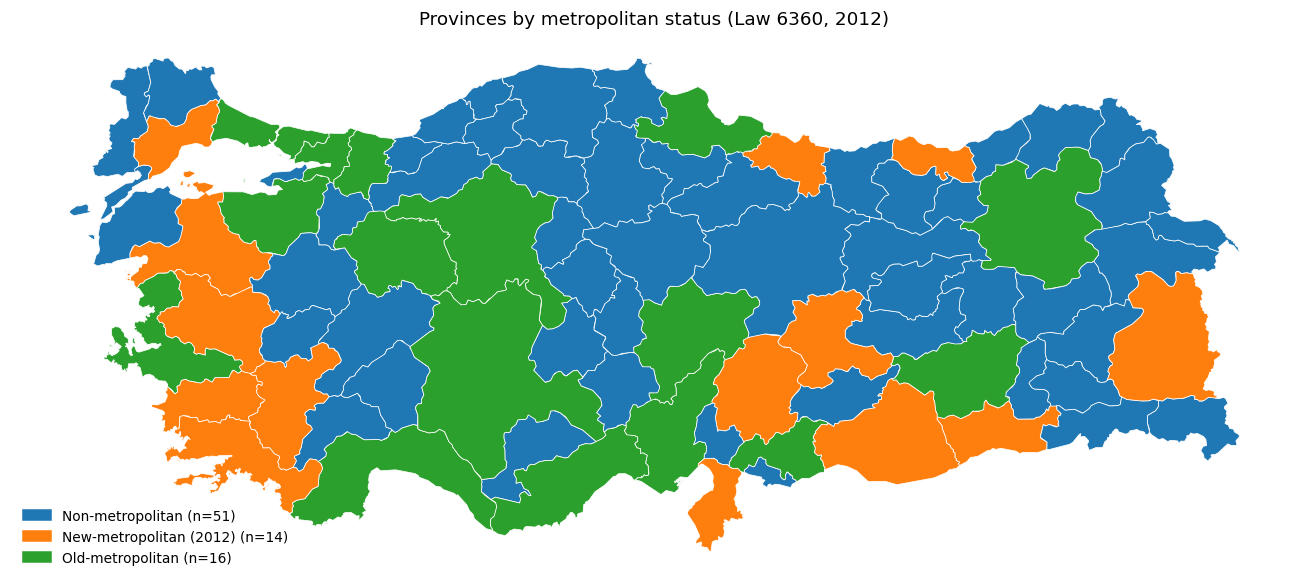

In [4]:
groups = fsoi_A[fsoi_A["Location_Name"] != "Türkiye"][["Location_Name", "Treated_Label"]].drop_duplicates()
g1 = provinces.merge(groups, on="Location_Name", how="left", validate="one_to_one")
assert g1["Treated_Label"].notna().all()

fig, ax = plt.subplots(figsize=(12, 5.5))
g1.plot(ax=ax, color=g1["Treated_Label"].map(GROUP_COLORS), edgecolor="white", linewidth=0.5)
ax.legend(handles=[Patch(color=c, label=f"{k} (n={int((g1.Treated_Label == k).sum())})")
                   for k, c in GROUP_COLORS.items()], loc="lower left", frameon=False, fontsize=9)
ax.set_title("Provinces by metropolitan status (Law 6360, 2012)")
ax.set_axis_off()
plt.tight_layout(); plt.show()

## Map 2 — Track C FSOI level, 2020 (choropleth)

Sequential colour scale for a level. Treated provinces are outlined in black so the treatment
pattern can be read against the score without a second map.

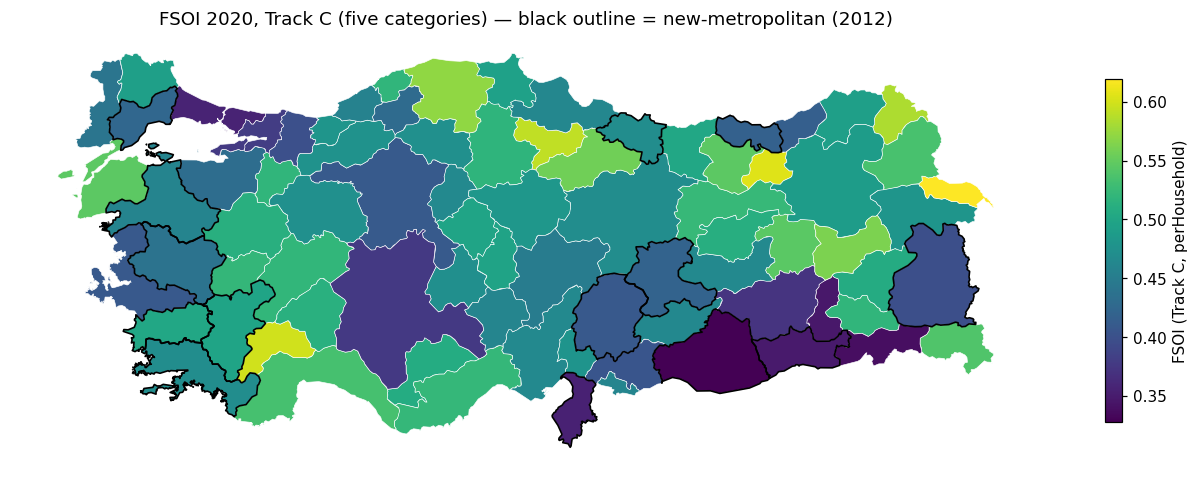

In [5]:
lvl = fsoi_C[(fsoi_C["Year"] == 2020) & (fsoi_C["Location_Name"] != "Türkiye")][["Location_Name", "FSOI", "Treated_Label"]]
g2 = provinces.merge(lvl, on="Location_Name", how="left", validate="one_to_one")
assert g2["FSOI"].notna().all()

fig, ax = plt.subplots(figsize=(12, 5.5))
g2.plot(ax=ax, column="FSOI", cmap="viridis", edgecolor="white", linewidth=0.4, legend=True,
        legend_kwds={"label": "FSOI (Track C, perHousehold)", "shrink": 0.6})
g2[g2["Treated_Label"] == "New-metropolitan (2012)"].boundary.plot(ax=ax, color="black", linewidth=1.1)
ax.set_title("FSOI 2020, Track C (five categories) — black outline = new-metropolitan (2012)")
ax.set_axis_off()
plt.tight_layout(); plt.show()

## Map 3 — FSOI by point (province centroids)

The same 2020 scores as points at each province's centroid: colour = FSOI, marker shape =
treatment group. Easier to compare small eastern provinces with large central ones, where a
choropleth lets area dominate the eye.

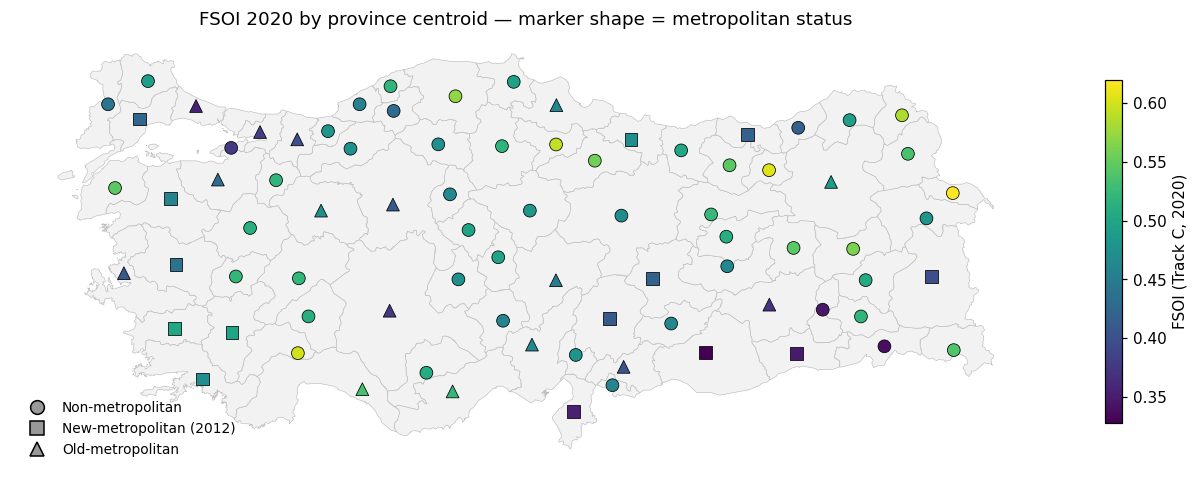

In [6]:
pts = g2.copy()
pts["geometry"] = gpd.points_from_xy(pts["center_lon"], pts["center_lat"], crs=pts.crs)
markers = {"Non-metropolitan": "o", "New-metropolitan (2012)": "s", "Old-metropolitan": "^"}

fig, ax = plt.subplots(figsize=(12, 5.5))
provinces.plot(ax=ax, color="#f2f2f2", edgecolor="#bbbbbb", linewidth=0.4)
vmin, vmax = pts["FSOI"].min(), pts["FSOI"].max()
for grp, mk in markers.items():
    sub = pts[pts["Treated_Label"] == grp]
    sc = ax.scatter(sub.geometry.x, sub.geometry.y, c=sub["FSOI"], cmap="viridis", vmin=vmin, vmax=vmax,
                    marker=mk, s=70, edgecolor="black", linewidth=0.5)
fig.colorbar(sc, ax=ax, shrink=0.6, label="FSOI (Track C, 2020)")
ax.legend(handles=[Line2D([0], [0], marker=mk, color="w", markerfacecolor="#999999",
                          markeredgecolor="black", markersize=9, label=grp) for grp, mk in markers.items()],
          loc="lower left", frameon=False, fontsize=9)
ax.set_title("FSOI 2020 by province centroid — marker shape = metropolitan status")
ax.set_axis_off()
plt.tight_layout(); plt.show()

## Map 4 — change in FSOI, 2012 → 2024 (Track A)

Diverging scale centred on zero: blue rose, red fell. Track A is used because it is the only
track that reaches 2024.

⚠️ **Do not read this as the causal effect of Law 6360.** It is a raw before/after change with
no control group and no fixed effects, and the one robust causal result in this project is a
municipal-coverage effect carried by `municipal_burden` — which is inside this composite. A
province turning red or blue here says nothing, on its own, about food sovereignty.

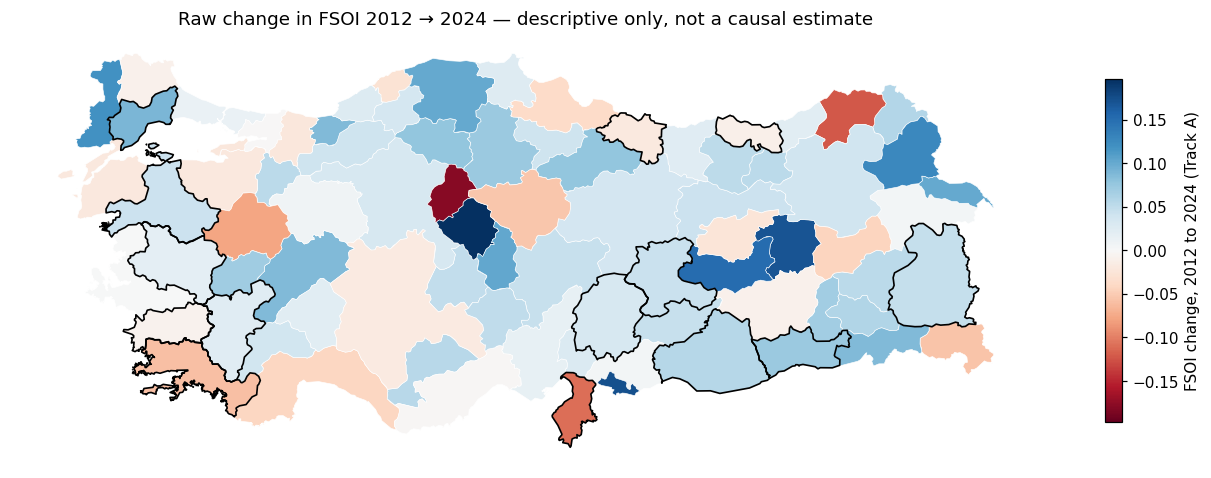

                           mean  median  count
Treated_Label                                 
New-metropolitan (2012)  0.0157  0.0285     14
Non-metropolitan         0.0420  0.0484     51
Old-metropolitan         0.0007  0.0001     16


In [7]:
chg = (fsoi_A[fsoi_A["Location_Name"] != "Türkiye"]
       .pivot(index="Location_Name", columns="Year", values="FSOI"))
chg = (chg[2024] - chg[2012]).rename("FSOI_change_2012_2024").reset_index()
g4 = provinces.merge(chg, on="Location_Name", how="left", validate="one_to_one")
assert g4["FSOI_change_2012_2024"].notna().all()

lim = g4["FSOI_change_2012_2024"].abs().max()
fig, ax = plt.subplots(figsize=(12, 5.5))
g4.plot(ax=ax, column="FSOI_change_2012_2024", cmap="RdBu", norm=TwoSlopeNorm(vmin=-lim, vcenter=0, vmax=lim),
        edgecolor="white", linewidth=0.4, legend=True,
        legend_kwds={"label": "FSOI change, 2012 to 2024 (Track A)", "shrink": 0.6})
g4.merge(groups, on="Location_Name").query("Treated_Label == 'New-metropolitan (2012)'").boundary.plot(
    ax=ax, color="black", linewidth=1.1)
ax.set_title("Raw change in FSOI 2012 → 2024 — descriptive only, not a causal estimate")
ax.set_axis_off()
plt.tight_layout(); plt.show()

print(g4.merge(groups, on="Location_Name").groupby("Treated_Label")["FSOI_change_2012_2024"]
      .agg(["mean", "median", "count"]).round(4))